# (IIP314W) Optimización Aplicada a Negocios
## Ayudantía 6: Método Simplex

---

**Profesor:** Ing. Rodrigo Trigo Vilches  
**Ayudante:** Lic. Vicente Ramírez Almonacid  
**Fecha:** 15 de Abril, 2026  
**Universidad del Desarrollo**

---

## 1. ¿Qué es el Método Simplex?

El **Método Simplex** (Dantzig, 1947) es el algoritmo clásico para resolver problemas de **Programación Lineal (PL)**. Dado un problema de la forma:

$$\max \quad z = c^\top x \qquad \text{s.a.} \quad Ax \leq b, \quad x \geq 0$$

### Fundamento Geométrico

La región factible de un PL es un **poliedro convexo**. Como la función objetivo es lineal, su máximo (o mínimo) siempre se alcanza en uno de los **vértices** (puntos extremos) del poliedro.

> El Simplex recorre de forma eficiente los vértices del poliedro, mejorando el valor de $z$ en cada paso, hasta alcanzar el óptimo.

### Forma Estándar y Bases

Para aplicar el algoritmo se introduce la **forma estándar**: se agregan variables de holgura $s_i \geq 0$ para convertir cada desigualdad en igualdad.

$$Ax \leq b \quad \xrightarrow{\text{holguras}} \quad [A \mid I]\begin{bmatrix}x \\ s\end{bmatrix} = b$$

Cada vértice del poliedro corresponde a una **Solución Básica Factible (SBF)**: exactamente $m$ variables son positivas (**variables básicas**, forman la base $B$) y el resto vale cero (**variables no básicas**).

### Reglas del Algoritmo

| Paso | Criterio | Descripción |
|:---:|:---|:---|
| 1 | **Optimalidad** | Si todos los costos reducidos son $\geq 0$, la SBF actual es óptima. |
| 2 | **Variable que entra** | La variable no básica con el costo reducido más negativo (regla de Dantzig). |
| 3 | **Variable que sale** | Cociente mínimo: $\min\{ b_i / a_{ik} \mid a_{ik} > 0 \}$ — garantiza factibilidad. |
| 4 | **Pivoteo** | Operación de Gauss-Jordan sobre la columna de entrada para actualizar el tableau. |

### Dos Implementaciones

| | Simplex Tableau | Simplex Matricial |
|:---|:---|:---|
| **Operación central** | Pivoteo fila a fila (Gauss-Jordan) | Cálculo de $B^{-1}$ en cada iteración |
| **Ventaja** | Visual e intuitivo | Sistemático y generalizable |
| **Uso típico** | Resolver a mano, aprendizaje | Implementación computacional, análisis de sensibilidad |

---

## 2. Ejercicio: Simplex Tableau

### Contexto

Una empresa de calzado deportivo fabrica dos modelos de zapatillas: **Runner** ($x_1$) y **Trail** ($x_2$). La empresa desea determinar cuántos pares de cada modelo producir por día para **maximizar su utilidad neta**.

| Recurso | Runner ($x_1$) | Trail ($x_2$) | Disponible |
|:---|:---:|:---:|:---:|
| Cuero reforzado (kg) | $1$ | $0$ | $4$ kg |
| Suela especial (unid.) | $0$ | $2$ | $12$ unid. |
| Horas de costura | $3$ | $2$ | $18$ hrs |
| **Utilidad (\$/par)** | **\$3** | **\$5** | — |

### Formulación

$$\max \quad z = 3x_1 + 5x_2$$

$$\text{s.a.} \quad \begin{cases} x_1 \leq 4 \\ 2x_2 \leq 12 \\ 3x_1 + 2x_2 \leq 18 \\ x_1, x_2 \geq 0 \end{cases}$$

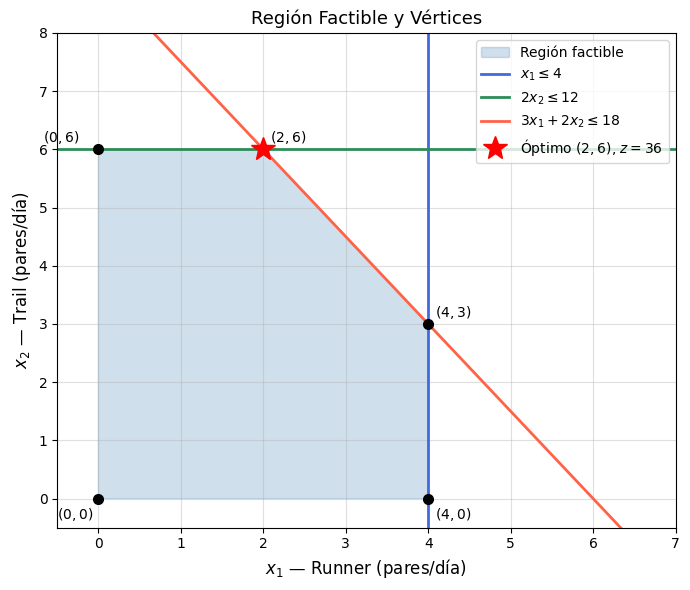

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

x1 = np.linspace(0, 7, 500)

# Fronteras de las restricciones
x2_r3 = (18 - 3 * x1) / 2

# Vértices de la región factible
vertices = np.array([[0, 0], [4, 0], [4, 3], [2, 6], [0, 6]])

fig, ax = plt.subplots(figsize=(7, 6))

# Región factible
poly = Polygon(vertices, alpha=0.25, color='steelblue', label='Región factible')
ax.add_patch(poly)

# Restricciones
ax.axvline(x=4, color='royalblue', linewidth=2, label='$x_1 \\leq 4$')
ax.axhline(y=6, color='seagreen', linewidth=2, label='$2x_2 \\leq 12$')
ax.plot(x1, x2_r3, color='tomato', linewidth=2, label='$3x_1 + 2x_2 \\leq 18$')

# Vértices
labels = ['$(0,0)$', '$(4,0)$', '$(4,3)$', '$(2,6)$', '$(0,6)$']
offsets = [(-30,-15), (5,-15), (5,5), (5,5), (-40,5)]
for v, lbl, off in zip(vertices, labels, offsets):
    ax.plot(v[0], v[1], 'ko', markersize=7, zorder=4)
    ax.annotate(lbl, v, textcoords='offset points', xytext=off, fontsize=10)

# Óptimo
ax.plot(2, 6, 'r*', markersize=18, zorder=5, label='Óptimo $(2,6)$, $z=36$')

ax.set_xlim(-0.5, 7)
ax.set_ylim(-0.5, 8)
ax.set_xlabel('$x_1$ — Runner (pares/día)', fontsize=12)
ax.set_ylabel('$x_2$ — Trail (pares/día)', fontsize=12)
ax.set_title('Región Factible y Vértices', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### Forma Estándar

Se introducen **variables de holgura** $x_3, x_4, x_5 \geq 0$:

$$\max \quad z = 3x_1 + 5x_2$$

$$\text{s.a.} \quad \begin{cases} x_1 + x_3 = 4 \\ 2x_2 + x_4 = 12 \\ 3x_1 + 2x_2 + x_5 = 18 \\ x_1, x_2, x_3, x_4, x_5 \geq 0 \end{cases}$$

**Base inicial:** $\{x_3, x_4, x_5\}$ — corresponde al vértice $(0,0)$, con $x_3=4,\; x_4=12,\; x_5=18$ y $z=0$.

### Tableau Inicial (Iteración 0)

La fila CR (costos reducidos) se inicializa con $-c$ para las variables de decisión (convenio para maximización):

| Base | $x_1$ | $x_2$ | $x_3$ | $x_4$ | $x_5$ | RHS |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **CR** | $-3$ | $\mathbf{-5}$ | $0$ | $0$ | $0$ | $0$ |
| $x_3$ | $1$ | $0$ | $1$ | $0$ | $0$ | $4$ |
| $x_4$ | $0$ | $2$ | $0$ | $1$ | $0$ | $12$ |
| $x_5$ | $3$ | $2$ | $0$ | $0$ | $1$ | $18$ |

**Criterio de entrada:** el costo reducido más negativo es $-5$ $\Rightarrow$ **entra $x_2$**.

**Criterio de salida** (cociente mínimo, solo filas con $a_{i2} > 0$):

| Fila | Cociente $b_i / a_{i2}$ |
|:---:|:---:|
| $x_3$ | $4/0 \;=\; \infty$ (no aplica) |
| $x_4$ | $12/2 = 6$ ← **mínimo** |
| $x_5$ | $18/2 = 9$ |

**Sale $x_4$**. Elemento pivote: $\boxed{a_{42} = 2}$.

### Iteración 1

**Operaciones de fila** (pivote en $a_{42} = 2$, fila de $x_4$):

$$R_{x_4}^{\text{nuevo}} = \frac{R_{x_4}}{2}$$
$$R_{\text{CR}}^{\text{nuevo}} = R_{\text{CR}} + 5 \cdot R_{x_4}^{\text{nuevo}}$$
$$R_{x_3}^{\text{nuevo}} = R_{x_3} - 0 \cdot R_{x_4}^{\text{nuevo}} \quad (\text{sin cambios})$$
$$R_{x_5}^{\text{nuevo}} = R_{x_5} - 2 \cdot R_{x_4}^{\text{nuevo}}$$

| Base | $x_1$ | $x_2$ | $x_3$ | $x_4$ | $x_5$ | RHS |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **CR** | $\mathbf{-3}$ | $0$ | $0$ | $5/2$ | $0$ | $30$ |
| $x_3$ | $1$ | $0$ | $1$ | $0$ | $0$ | $4$ |
| $x_2$ | $0$ | $1$ | $0$ | $1/2$ | $0$ | $6$ |
| $x_5$ | $3$ | $0$ | $0$ | $-1$ | $1$ | $6$ |

**Solución parcial:** $x_2 = 6,\; x_3 = 4,\; x_5 = 6$, $z = 30$. El algoritmo visitó el vértice $(0, 6)$.

**Criterio de entrada:** costo reducido más negativo es $-3$ $\Rightarrow$ **entra $x_1$**.

**Criterio de salida:**

| Fila | Cociente $b_i / a_{i1}$ |
|:---:|:---:|
| $x_3$ | $4/1 = 4$ |
| $x_2$ | $6/0 \;=\; \infty$ (no aplica) |
| $x_5$ | $6/3 = 2$ ← **mínimo** |

**Sale $x_5$**. Elemento pivote: $\boxed{a_{51} = 3}$.

### Iteración 2 — Solución Óptima

**Operaciones de fila** (pivote en $a_{51} = 3$, fila de $x_5$):

$$R_{x_5}^{\text{nuevo}} = \frac{R_{x_5}}{3}$$
$$R_{\text{CR}}^{\text{nuevo}} = R_{\text{CR}} + 3 \cdot R_{x_5}^{\text{nuevo}}$$
$$R_{x_3}^{\text{nuevo}} = R_{x_3} - 1 \cdot R_{x_5}^{\text{nuevo}}$$
$$R_{x_2}^{\text{nuevo}} = R_{x_2} - 0 \cdot R_{x_5}^{\text{nuevo}} \quad (\text{sin cambios})$$

| Base | $x_1$ | $x_2$ | $x_3$ | $x_4$ | $x_5$ | RHS |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **CR** | $0$ | $0$ | $0$ | $3/2$ | $1$ | $\mathbf{36}$ |
| $x_3$ | $0$ | $0$ | $1$ | $1/3$ | $-1/3$ | $2$ |
| $x_2$ | $0$ | $1$ | $0$ | $1/2$ | $0$ | $6$ |
| $x_1$ | $1$ | $0$ | $0$ | $-1/3$ | $1/3$ | $2$ |

**Todos los costos reducidos son $\geq 0$ $\Rightarrow$ Solución Óptima alcanzada.**

$$\boxed{x_1^* = 2, \quad x_2^* = 6, \quad z^* = 36}$$

La empresa debe producir **2 pares Runner y 6 pares Trail** por día para obtener una utilidad máxima de **\$36**.

**Interpretación de restricciones:**
- $x_3 = 2 > 0$: la restricción de cuero **no está activa** (sobran 2 kg).
- $x_4 = 0$: la restricción de suela especial **está activa** ($2 \cdot 6 = 12$).
- $x_5 = 0$: la restricción de horas de costura **está activa** ($3 \cdot 2 + 2 \cdot 6 = 18$).

El simplex pasó por los vértices: $(0,0) \to (0,6) \to (2,6)$.

In [2]:
from scipy.optimize import linprog

# linprog minimiza → negamos la función objetivo
c_obj = [-3, -5]

A_ub = [[1, 0],
        [0, 2],
        [3, 2]]
b_ub = [4, 12, 18]

bounds = [(0, None), (0, None)]

res = linprog(c_obj, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

print("Verificación con scipy:")
print(f"  x1 (Runner) = {res.x[0]:.4f}")
print(f"  x2 (Trail)  = {res.x[1]:.4f}")
print(f"  z*          = {-res.fun:.4f}")

Verificación con scipy:
  x1 (Runner) = 2.0000
  x2 (Trail)  = 6.0000
  z*          = 36.0000


---

## 3. Mismo Ejercicio: Simplex Matricial

El **Simplex Matricial** resuelve el mismo problema usando operaciones matriciales en lugar de pivoteo fila a fila. En cada iteración se actualiza la **base** $B$ (matriz cuyas columnas corresponden a las variables básicas del sistema $[A \mid I]$) y se calculan:

| Fórmula | Descripción |
|:---|:---|
| $c_B B^{-1} A_{NB} - c_{NB}$ | Costos reducidos de las variables no básicas |
| $B^{-1} a_k$ | Columna actualizada de la variable $k$ que entra |
| $B^{-1} b$ | Valores actuales de las variables básicas (RHS) |
| $c_B B^{-1} b$ | Valor actual de la función objetivo |

### Sistema $[A \mid I]$

Las columnas del sistema completo (variables $x_1, \ldots, x_5$) son:

$$[A \mid I] = \begin{bmatrix} 1 & 0 & 1 & 0 & 0 \\ 0 & 2 & 0 & 1 & 0 \\ 3 & 2 & 0 & 0 & 1 \end{bmatrix}$$

In [3]:
import numpy as np
from numpy.linalg import inv

# RHS del sistema
b = np.array([4, 12, 18], dtype=float)

# Columnas del sistema [A | I] para cada variable
cols = {
    'x1': np.array([1, 0, 3], dtype=float),
    'x2': np.array([0, 2, 2], dtype=float),
    'x3': np.array([1, 0, 0], dtype=float),
    'x4': np.array([0, 1, 0], dtype=float),
    'x5': np.array([0, 0, 1], dtype=float),
}

# Coeficientes en la función objetivo
c_obj = {'x1': 3, 'x2': 5, 'x3': 0, 'x4': 0, 'x5': 0}

### Iteración 0

**Base:** $\{x_3, x_4, x_5\}$

**Paso 1 — Construir $B$ y $c_B$**

$$B = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix} = I_3 \qquad c_B = [0,\; 0,\; 0]$$

**Paso 2 — Calcular $B^{-1}$**

$$B^{-1} = I_3$$

**Paso 3 — Costos reducidos** (variables no básicas: $x_1, x_2$)

$$A_{NB} = \begin{bmatrix} 1 & 0 \\ 0 & 2 \\ 3 & 2 \end{bmatrix} \qquad c_{NB} = [3,\; 5]$$

$$\bar{c} = c_B B^{-1} A_{NB} - c_{NB} = [0,0,0]\cdot I_3 \cdot A_{NB} - [3,5] = \mathbf{[-3,\; -5]}$$

Costo reducido más negativo: $-5$ $\Rightarrow$ **entra $x_2$**

**Paso 4 — Prueba del cociente**

Columna de $x_2$: $\quad B^{-1} a_{x_2} = [0,\; 2,\; 2]^\top$

RHS actualizado: $\quad B^{-1}b = [4,\; 12,\; 18]^\top$

| Base | $B^{-1}b$ | $B^{-1}a_{x_2}$ | Cociente |
|:---:|:---:|:---:|:---:|
| $x_3$ | $4$ | $0$ | $\infty$ (no aplica) |
| $x_4$ | $12$ | $2$ | $12/2 = \mathbf{6}$ ← mínimo |
| $x_5$ | $18$ | $2$ | $18/2 = 9$ |

**Sale $x_4$** $\;\Rightarrow\;$ Nueva base: $\{x_3,\; x_2,\; x_5\}$

In [ ]:
# --- Iteración 0 ---
base    = ['x3', 'x4', 'x5']
nonbase = ['x1', 'x2']

B       = np.column_stack([cols[v] for v in base])
cB      = np.array([c_obj[v] for v in base], dtype=float)
Binv    = inv(B)

A_nb    = np.column_stack([cols[v] for v in nonbase])
c_nb    = np.array([c_obj[v] for v in nonbase], dtype=float)

cr      = cB @ Binv @ A_nb - c_nb   # costos reducidos
rhs     = Binv @ b                  # valores de variables básicas
z       = cB @ Binv @ b             # valor objetivo

print("=" * 50)
print(f"Iteración 0 | Base: {base}")
print("=" * 50)
print(f"  B =\n{B}")
print(f"  B⁻¹ =\n{np.round(Binv, 4)}")
print(f"  c_B B⁻¹ A_NB - c_NB  ({nonbase}): {cr}")
print(f"  B⁻¹ b                 ({base}): {rhs}")
print(f"  z = c_B B⁻¹ b = {z}")

# Identificar variable que entra
idx_entra = np.argmin(cr)
var_entra = nonbase[idx_entra]
print(f"\n  Costo reducido más negativo: {var_entra} ({cr[idx_entra]:.2f}) → ENTRA {var_entra}")

# Prueba del cociente
col_entra = Binv @ cols[var_entra]
print(f"\n  Columna actualizada de {var_entra}: {col_entra}")
print(f"  RHS actualizado: {rhs}")
print("  Cocientes (solo a_ik > 0):")
ratios = []
for i, (aik, bi) in enumerate(zip(col_entra, rhs)):
    if aik > 1e-9:
        r = bi / aik
        ratios.append((r, base[i]))
        print(f"    {base[i]}: {bi:.4f} / {aik:.4f} = {r:.4f}")
    else:
        print(f"    {base[i]}: {aik:.4f} ≤ 0, no aplica")
var_sale = min(ratios, key=lambda x: x[0])[1]
print(f"  → Cociente mínimo: {var_sale} → SALE {var_sale}")

Iteración 0 | Base: ['x3', 'x4', 'x5']
  B =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
  B⁻¹ =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
  c_B B⁻¹ A_NB - c_NB  (['x1', 'x2']): [-3. -5.]
  B⁻¹ b                 (['x3', 'x4', 'x5']): [ 4. 12. 18.]
  z = c_B B⁻¹ b = 0.0

  Costo reducido más negativo: x2 (-5.00) → ENTRA x2

  Columna actualizada de x2: [0. 2. 2.]
  RHS actualizado: [ 4. 12. 18.]
  Cocientes (solo a_ik > 0):
    x3: 0.0000 ≤ 0, no aplica
    x4: 12.0000 / 2.0000 = 6.0000
    x5: 18.0000 / 2.0000 = 9.0000
  → Cociente mínimo: x4 → SALE x4


### Iteración 1

**Base:** $\{x_3, x_2, x_5\}$

**Paso 1 — Construir $B$ y $c_B$**

Las columnas de $B$ son $a_{x_3}, a_{x_2}, a_{x_5}$ del sistema $[A \mid I]$:

$$B = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 2 & 0 \\ 0 & 2 & 1 \end{bmatrix} \qquad c_B = [0,\; 5,\; 0]$$

**Paso 2 — Calcular $B^{-1}$**

$$B^{-1} = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1/2 & 0 \\ 0 & -1 & 1 \end{bmatrix}$$

**Paso 3 — Costos reducidos** (variables no básicas: $x_1, x_4$)

$$A_{NB} = \begin{bmatrix} 1 & 0 \\ 0 & 1 \\ 3 & 0 \end{bmatrix} \qquad c_{NB} = [3,\; 0]$$

$$B^{-1} A_{NB} = \begin{bmatrix} 1 & 0 \\ 0 & 1/2 \\ 3 & -1 \end{bmatrix}$$

$$\bar{c} = c_B B^{-1} A_{NB} - c_{NB} = [0,5,0]\begin{bmatrix} 1 & 0 \\ 0 & 1/2 \\ 3 & -1 \end{bmatrix} - [3,0] = [0,\;5/2] - [3,\;0] = \mathbf{[-3,\; 5/2]}$$

Costo reducido más negativo: $-3$ $\Rightarrow$ **entra $x_1$**

**Paso 4 — Prueba del cociente**

Columna de $x_1$: $\quad B^{-1} a_{x_1} = [1,\; 0,\; 3]^\top$

RHS actualizado: $\quad B^{-1}b = [4,\; 6,\; 6]^\top$

| Base | $B^{-1}b$ | $B^{-1}a_{x_1}$ | Cociente |
|:---:|:---:|:---:|:---:|
| $x_3$ | $4$ | $1$ | $4/1 = 4$ |
| $x_2$ | $6$ | $0$ | $\infty$ (no aplica) |
| $x_5$ | $6$ | $3$ | $6/3 = \mathbf{2}$ ← mínimo |

**Sale $x_5$** $\;\Rightarrow\;$ Nueva base: $\{x_3,\; x_2,\; x_1\}$

In [5]:
# --- Iteración 1 ---
base    = ['x3', 'x2', 'x5']
nonbase = ['x1', 'x4']

B    = np.column_stack([cols[v] for v in base])
cB   = np.array([c_obj[v] for v in base], dtype=float)
Binv = inv(B)

A_nb = np.column_stack([cols[v] for v in nonbase])
c_nb = np.array([c_obj[v] for v in nonbase], dtype=float)

cr  = cB @ Binv @ A_nb - c_nb
rhs = Binv @ b
z   = cB @ Binv @ b

print("=" * 50)
print(f"Iteración 1 | Base: {base}")
print("=" * 50)
print(f"  B =\n{B}")
print(f"  B⁻¹ =\n{np.round(Binv, 4)}")
print(f"  c_B B⁻¹ A_NB - c_NB  ({nonbase}): {np.round(cr, 4)}")
print(f"  B⁻¹ b                 ({base}): {np.round(rhs, 4)}")
print(f"  z = c_B B⁻¹ b = {z}")

# Identificar variable que entra
idx_entra = np.argmin(cr)
var_entra = nonbase[idx_entra]
print(f"\n  Costo reducido más negativo: {var_entra} ({cr[idx_entra]:.4f}) → ENTRA {var_entra}")

# Prueba del cociente
col_entra = Binv @ cols[var_entra]
print(f"\n  Columna actualizada de {var_entra}: {np.round(col_entra, 4)}")
print(f"  RHS actualizado: {np.round(rhs, 4)}")
print("  Cocientes (solo a_ik > 0):")
ratios = []
for i, (aik, bi) in enumerate(zip(col_entra, rhs)):
    if aik > 1e-9:
        r = bi / aik
        ratios.append((r, base[i]))
        print(f"    {base[i]}: {bi:.4f} / {aik:.4f} = {r:.4f}")
    else:
        print(f"    {base[i]}: {aik:.4f} ≤ 0, no aplica")
var_sale = min(ratios, key=lambda x: x[0])[1]
print(f"  → Cociente mínimo: {var_sale} → SALE {var_sale}")

Iteración 1 | Base: ['x3', 'x2', 'x5']
  B =
[[1. 0. 0.]
 [0. 2. 0.]
 [0. 2. 1.]]
  B⁻¹ =
[[ 1.   0.   0. ]
 [ 0.   0.5  0. ]
 [ 0.  -1.   1. ]]
  c_B B⁻¹ A_NB - c_NB  (['x1', 'x4']): [-3.   2.5]
  B⁻¹ b                 (['x3', 'x2', 'x5']): [4. 6. 6.]
  z = c_B B⁻¹ b = 30.0

  Costo reducido más negativo: x1 (-3.0000) → ENTRA x1

  Columna actualizada de x1: [1. 0. 3.]
  RHS actualizado: [4. 6. 6.]
  Cocientes (solo a_ik > 0):
    x3: 4.0000 / 1.0000 = 4.0000
    x2: 0.0000 ≤ 0, no aplica
    x5: 6.0000 / 3.0000 = 2.0000
  → Cociente mínimo: x5 → SALE x5


### Iteración 2 — Solución Óptima

**Base:** $\{x_3, x_2, x_1\}$

**Paso 1 — Construir $B$ y $c_B$**

$$B = \begin{bmatrix} 1 & 0 & 1 \\ 0 & 2 & 0 \\ 0 & 2 & 3 \end{bmatrix} \qquad c_B = [0,\; 5,\; 3]$$

**Paso 2 — Calcular $B^{-1}$**

$$B^{-1} = \begin{bmatrix} 1 & 1/3 & -1/3 \\ 0 & 1/2 & 0 \\ 0 & -1/3 & 1/3 \end{bmatrix}$$

**Paso 3 — Costos reducidos** (variables no básicas: $x_4, x_5$)

$$A_{NB} = \begin{bmatrix} 0 & 0 \\ 1 & 0 \\ 0 & 1 \end{bmatrix} \qquad c_{NB} = [0,\; 0]$$

$$B^{-1} A_{NB} = \begin{bmatrix} 1/3 & -1/3 \\ 1/2 & 0 \\ -1/3 & 1/3 \end{bmatrix}$$

$$\bar{c} = c_B B^{-1} A_{NB} - c_{NB} = [0,5,3]\begin{bmatrix} 1/3 & -1/3 \\ 1/2 & 0 \\ -1/3 & 1/3 \end{bmatrix} - [0,0] = \mathbf{[3/2,\; 1]}$$

**Todos los costos reducidos son $\geq 0$ $\Rightarrow$ Condición de optimalidad satisfecha.**

**Paso 5 — Solución óptima**

$$B^{-1}b = \begin{bmatrix} 1 & 1/3 & -1/3 \\ 0 & 1/2 & 0 \\ 0 & -1/3 & 1/3 \end{bmatrix} \begin{bmatrix} 4 \\ 12 \\ 18 \end{bmatrix} = \begin{bmatrix} 2 \\ 6 \\ 2 \end{bmatrix} \;\Rightarrow\; x_3=2,\; x_2=6,\; x_1=2$$

$$z^* = c_B \cdot B^{-1}b = [0,5,3]\cdot[2,6,2]^\top = 0 + 30 + 6 = \mathbf{36}$$

In [6]:
# --- Iteración 2 ---
base    = ['x3', 'x2', 'x1']
nonbase = ['x4', 'x5']

B    = np.column_stack([cols[v] for v in base])
cB   = np.array([c_obj[v] for v in base], dtype=float)
Binv = inv(B)

A_nb = np.column_stack([cols[v] for v in nonbase])
c_nb = np.array([c_obj[v] for v in nonbase], dtype=float)

cr  = cB @ Binv @ A_nb - c_nb
rhs = Binv @ b
z   = cB @ Binv @ b

print("=" * 50)
print(f"Iteración 2 | Base: {base}")
print("=" * 50)
print(f"  B =\n{B}")
print(f"  B⁻¹ =\n{np.round(Binv, 4)}")
print(f"  c_B B⁻¹ A_NB - c_NB  ({nonbase}): {np.round(cr, 4)}")
print(f"  B⁻¹ b                 ({base}): {np.round(rhs, 4)}")
print(f"  z = c_B B⁻¹ b = {z}")

if all(cr >= -1e-9):
    print("\n  ✓ Todos los costos reducidos ≥ 0 → SOLUCIÓN ÓPTIMA")
    print("\n  Solución:")
    for var, val in zip(base, rhs):
        print(f"    {var} = {val:.4f}")
    for var in nonbase:
        print(f"    {var} = 0.0000 (no básica)")
    print(f"\n    z* = {z:.4f}")

Iteración 2 | Base: ['x3', 'x2', 'x1']
  B =
[[1. 0. 1.]
 [0. 2. 0.]
 [0. 2. 3.]]
  B⁻¹ =
[[ 1.      0.3333 -0.3333]
 [ 0.      0.5     0.    ]
 [ 0.     -0.3333  0.3333]]
  c_B B⁻¹ A_NB - c_NB  (['x4', 'x5']): [1.5 1. ]
  B⁻¹ b                 (['x3', 'x2', 'x1']): [2. 6. 2.]
  z = c_B B⁻¹ b = 36.0

  ✓ Todos los costos reducidos ≥ 0 → SOLUCIÓN ÓPTIMA

  Solución:
    x3 = 2.0000
    x2 = 6.0000
    x1 = 2.0000
    x4 = 0.0000 (no básica)
    x5 = 0.0000 (no básica)

    z* = 36.0000


### Resumen Comparativo

Ambos métodos llegan a la misma solución en 2 iteraciones:

| Iteración | Vértice visitado | Base | $z$ |
|:---:|:---:|:---:|:---:|
| 0 | $(0, 0)$ | $\{x_3, x_4, x_5\}$ | $0$ |
| 1 | $(0, 6)$ | $\{x_3, x_2, x_5\}$ | $30$ |
| 2 | $(2, 6)$ ← **óptimo** | $\{x_3, x_2, x_1\}$ | $\mathbf{36}$ |

$$\boxed{x_1^* = 2 \text{ pares Runner}, \quad x_2^* = 6 \text{ pares Trail}, \quad z^* = \$36}$$

> **Tableau vs. Matricial:** En el tableau se opera directamente sobre las filas (útil a mano). En el matricial, calcular $B^{-1}$ explícitamente permite extender el algoritmo hacia el **análisis de sensibilidad**: basta con perturbar $b$ o $c$ y recalcular $B^{-1}b$ o $c_B B^{-1}A$ sin re-ejecutar el algoritmo completo desde cero.